# Internações × Qualidade do Ar — Rio de Janeiro

**Objetivo:** consolidar e sincronizar séries temporais diárias de qualidade do ar (estações QUALIAR/DataRio) com registros de internações por doenças respiratórias (DATASUS) para análise exploratória e modelagem preditiva.

**Escopo:**
- Agregar séries diárias de poluentes e variáveis meteorológicas às contagens diárias de internações respiratórias;
- Gerar features temporais (lags, médias móveis, janelas causais), indicadores de calendário e avaliar impacto de poluentes nas internações;
- Estimar modelos preditivos (Random Forest, HistGradientBoosting, LSTM) e calcular intervalos de incerteza (conformal pairs).

**CID-10 considerados:** J15, J18 (pneumonias), J21 (bronquiolite), J96 (insuficiência respiratória), J40–J42 (bronquites), J43–J44 (DPOC/enfisema), J45–J46 (asma).


## 1) Configurações e importações
Breve setup de bibliotecas utilizadas.

In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.tree import export_text

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## 2) Unificação dos datasets (Internações × Ambiente)
Carrega CSVs do GitHub (QUALIAR/DataRio e DATASUS), faz *merge* por data e salva um CSV consolidado.

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/Qualiar/INTERNACOES_DOENCA_RESP_RJ_QUALIAR_FEATURES.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/Qualiar/INTERNACOES_DOENCA_RESP_RJ_SEAZONALITY_FEATURES.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_internacoes, df_qualiar, on="data_dia", how="left")
    .sort_values("data_dia")
    .reset_index(drop=True)
)

# Agora o 'target' “bom” está no lado esquerdo (internações) -> target_x
df_unificado.drop(columns=["ano", "mes", "dia", 'target_y', 'estacao', 'estacao_id', 'dow'], inplace=True, errors="ignore")
df_unificado.rename(columns={"target_x": "y"}, inplace=True)

# Garante tipo numérico de y
df_unificado["y"] = pd.to_numeric(df_unificado["y"], errors="coerce").astype(float)

print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
display(df_unificado.head())
print("\nTipos de dados:")
print(df_unificado.dtypes)

Dimensões do unificado: (4748, 42)
Intervalo de datas: 2012-01-01 → 2024-12-30

Colunas: ['data_dia', 'y', 'no_t', 'no2_t', 'nox_t', 'o3_t', 'nox_x_o3_t', 'no_lag1', 'no_lag7', 'o3_lag1', 'o3_lag7', 'pm10_lag1', 'pm2_5_lag1', 'so2_lag12', 'no_ma60_s1', 'nox_ma60_s1', 'no2_ma30_s1', 'o3_ma150_s1', 'so2_ma150_s21', 'pm10_ma30_s1', 'pm2_5_ma7_s1', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'ma_3', 'ma_7', 'ma_14', 'mes_sin', 'mes_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_monday', 'stl365_seasonal', 'stl365_resid_vol30', 'stl365_season_amp', 'estacao_sin', 'estacao_cos']


,data_dia,y,no_t,no2_t,nox_t,o3_t,nox_x_o3_t,no_lag1,no_lag7,o3_lag1,...,mes_cos,dow_sin,dow_cos,is_weekend,is_monday,stl365_seasonal,stl365_resid_vol30,stl365_season_amp,estacao_sin,estacao_cos
0,2012-01-01,507.0,1.256189,4.184802,2.770516,6.469835,17.924784,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-02,728.0,1.884591,4.419030,3.019050,6.013862,18.156151,1.256189,NaN,6.469835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-01-03,429.0,2.021231,4.512331,3.108324,5.246714,16.308486,1.884591,NaN,6.013862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-01-04,416.0,2.175012,5.096621,3.324094,6.754888,22.453881,2.021231,NaN,5.246714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-01-05,403.0,2.007440,4.843477,3.181217,7.889395,25.097879,2.175012,NaN,6.754888,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Tipos de dados:
data_dia               object
y                     float64
no_t                  float64
no2_t                 float64
nox_t                 float64
o3_t                  float64
nox_x_o3_t            float64
no_lag1               float64
no_lag7               float64
o3_lag1               float64
o3_lag7               float64
pm10_lag1             float64
pm2_5_lag1            float64
so2_lag12             float64
no_ma60_s1            float64
nox_ma60_s1           float64
no2_ma30_s1           float64
o3_ma150_s1           float64
so2_ma150_s21         float64
pm10_ma30_s1          float64
pm2_5_ma7_s1          float64
lag_1                 float64
lag_2                 float64
lag_3                 float64
lag_4                 float64
lag_5                 float64
lag_6                 float64
lag_7                 float64
ma_3                  float64
ma_7                  float64
ma_14                 float64
mes_sin               float64
mes_cos               f

## 3) Série temporal das internações
Visualiza a série diária com média móvel de 7 dias e a média global.

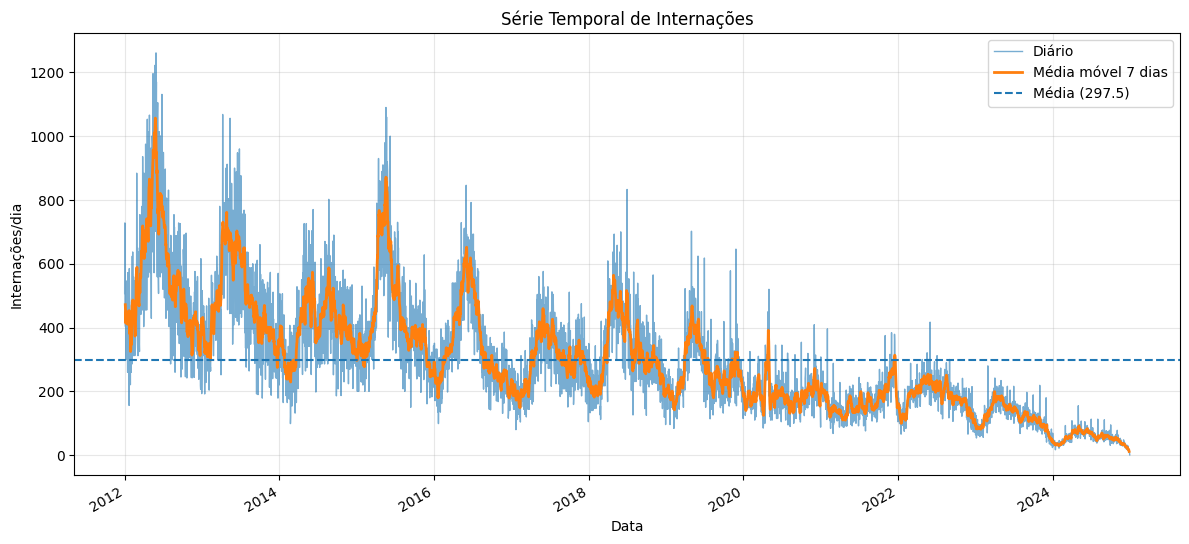

In [3]:
ts = df_unificado.set_index(pd.to_datetime(df_unificado['data_dia']))['y']

plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Diário', alpha=0.6, linewidth=1)
plt.plot(ts.index, ts.rolling(7, center=True).mean(), label='Média móvel 7 dias', linewidth=2)
mean_val = ts.mean()
plt.axhline(mean_val, linestyle='--', linewidth=1.5, label=f'Média ({mean_val:.1f})')
plt.title('Série Temporal de Internações')
plt.xlabel('Data'); plt.ylabel('Internações/dia')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.gcf().autofmt_xdate()

## 5) Funções auxiliares — calendário contínuo e imputação causal
Cria calendário diário sem buracos e **não** preenche o alvo (y).

In [4]:
def make_daily_frame(
    df: pd.DataFrame,
    date_col: str,
    target_col: str,
    ffill_limit: int = 14,
    categorical_cols: List[str] | None = None
) -> pd.DataFrame:
    """
    - Cria índice diário contínuo.
    - Adiciona colunas *_missing indicando onde faltou dado.
    - Faz forward-fill limitado nos preditores numéricos e categóricos.
    - NÃO altera o alvo (target_col).
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.sort_values(date_col).set_index(date_col)

    # índice diário completo
    full_idx = pd.date_range(data.index.min(), data.index.max(), freq='D')
    data = data.reindex(full_idx)

    if categorical_cols is None:
        categorical_cols = []

    # detecta numéricas, exceto o y
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        num_cols.remove(target_col)

    # detecta categóricas explícitas
    cat_cols = [c for c in categorical_cols if c in data.columns]

    # flags de missing ANTES de preencher
    for c in num_cols + cat_cols:
        data[f"{c}_missing"] = data[c].isna().astype(int)

    # forward fill limitado (não usa info do futuro distante)
    for c in num_cols:
        data[c] = data[c].ffill(limit=ffill_limit)

    for c in cat_cols:
        data[c] = data[c].ffill(limit=min(3, ffill_limit))

    return data

## 6) Janelas causais (rolling window) → dataset tabular
Aplica janela deslizante e achata para colunas do tipo `feat_t-1`, `feat_t-2`, ...

In [5]:
def apply_rolling_window(
    time_series_array: np.ndarray,
    initial_time_step: int,
    max_time_step: int,
    window_size: int,
    target_idx: int
):
    """
    Cria janelas causais:
    X -> [amostras, janela, n_features]
    y -> [amostras] (valor de y imediatamente após a janela)
    """
    assert 0 <= target_idx < time_series_array.shape[1]
    assert initial_time_step >= 0
    assert max_time_step >= initial_time_step

    start = initial_time_step
    sub_windows = (
        start +
        np.expand_dims(np.arange(window_size), 0) +
        np.expand_dims(np.arange(max_time_step + 1), 0).T
    )

    # X3d
    X = time_series_array[sub_windows]

    # alvo é o próximo passo após a janela
    y = time_series_array[
        window_size:(max_time_step+window_size+1):1,
        target_idx
    ]

    idx_y_train_not_nan = np.where(~np.isnan(y))[0]
    assert len(idx_y_train_not_nan) == len(y), 'Há y NaN — ajuste construção de janelas.'
    _ = np.unique(np.where(np.isnan(X)))  # X pode ter NaN -> vamos imputar depois p/ LSTM

    return X, y


def rolling_to_tabular(
    df_windowed: pd.DataFrame,
    window_size: int,
    target_col: str,
    date_index: pd.DatetimeIndex
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, List[str]]:
    """
    Converte a série multivariada em:
    - X_flat (2D) p/ modelos tabulares (RF)
    - y (1D) alvo
    - X_seq (3D) p/ modelos sequenciais (LSTM)
    - seq_cols (ordem das colunas originais nos canais da sequência)
    """
    cols = df_windowed.columns.tolist()
    target_idx = cols.index(target_col)

    A = df_windowed.to_numpy()
    max_ts = len(df_windowed) - window_size - 1

    X3d, y = apply_rolling_window(
        A,
        initial_time_step=0,
        max_time_step=max_ts,
        window_size=window_size,
        target_idx=target_idx
    )

    # Achata X3d -> X2d (lags explodidos) para RF
    ns, w, nf = X3d.shape
    X2d = X3d.reshape(ns, w * nf)

    names = []
    for lag in range(1, window_size+1):
        for c in cols:
            names.append(f"{c}_t-{lag}")

    idx = date_index[window_size:(max_ts+window_size+1)]
    X_flat = pd.DataFrame(X2d, columns=names, index=idx)

    return X_flat, y, X3d, cols

## 7) Métricas e pesos de recência
Funções utilitárias para avaliação e ponderação temporal.

In [6]:
def make_recency_weights(
    index: pd.DatetimeIndex,
    low: float = 0.5,
    high: float = 1.5
) -> pd.Series:
    """
    Gera pesos maiores para amostras mais recentes.
    """
    t = (index - index.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return pd.Series(w, index=index).clip(lower=low, upper=high)


def smape(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return 100*np.mean(
        2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9)
    )


def wmape(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)


def evaluate_predictions(y_true, y_pred) -> Dict[str, float]:
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'WMAPE': wmape(y_true, y_pred),
    }

## 8) Seleção de features via Permutation Importance (para RF) *Permutation Importance*
Seleciona as `k` melhores variáveis no último *fold* (mais recente).

In [7]:
def select_top_features(
    X: pd.DataFrame,
    y: np.ndarray,
    pre: ColumnTransformer,
    n_splits: int = 4,
    random_state: int = 42,
    k: int = 8
) -> List[str]:
    """
    Treina RF simples no último fold (mais recente),
    calcula importance via permutação no conjunto de validação,
    e retorna as top-k features.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    base_rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        random_state=random_state,
        n_jobs=-1
    )

    ttr = TransformedTargetRegressor(
        regressor=base_rf,
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe = Pipeline([
        ('pre', pre),
        ('rf', ttr)
    ])

    folds = list(tscv.split(X))
    tr_idx, va_idx = folds[-1]  # último fold (mais recente)

    Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
    ytr, yva = y[tr_idx], y[va_idx]

    pipe.fit(Xtr, ytr)

    imp = permutation_importance(
        pipe,
        Xva,
        yva,
        n_repeats=10,
        random_state=random_state,
        scoring='neg_mean_absolute_error'
    )

    importances = pd.Series(
        imp.importances_mean,
        index=X.columns
    ).sort_values(ascending=False)

    return importances.head(k).index.tolist()

## 9) Random Forest + busca rápida de hiperparâmetros
Modelo com capacidade limitada para reduzir *overfitting*.

In [8]:
def tune_and_fit_rf_simplified(
    X: pd.DataFrame,
    y: np.ndarray,
    preprocessor: ColumnTransformer,
    n_splits: int = 5,
    random_state: int = 42
) -> Pipeline:
    """
    Pipeline(preprocess -> TTR(RandomForest)) +
    RandomizedSearchCV com validação temporal.
    """
    base_rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=random_state
    )

    ttr = TransformedTargetRegressor(
        regressor=base_rf,
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe = Pipeline([
        ('pre', preprocessor),
        ('rf', ttr)
    ])

    param_dist = {
        'rf__regressor__n_estimators': [300, 400, 600],
        'rf__regressor__max_depth': [8, 12, 16],
        'rf__regressor__min_samples_leaf': [5, 10, 20],
        'rf__regressor__min_samples_split': [5, 10, 20],
        'rf__regressor__max_features': ['sqrt', 0.5],
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)

    # pesos de recência dão mais importância aos dados mais novos
    rec_w = make_recency_weights(X.index, low=0.7, high=2).values

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=12,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=random_state,
        refit=True,
        verbose=0
    )

    search.fit(X, y, rf__sample_weight=rec_w)

    return search.best_estimator_

## 10) Funções de inspeção e plot das previsões (RF)
Funções para auditar regras e visualizar observado × previsto.

In [9]:
def print_one_tree(
    model: Pipeline,
    feature_names: List[str],
    estimator_idx: int = 0
) -> None:
    """
    Imprime uma árvore individual do Random Forest
    (boa p/ interpretar regras).
    """
    rf = model.named_steps['rf'].regressor_
    tree = rf.estimators_[estimator_idx]

    txt = export_text(
        tree,
        feature_names=feature_names[:tree.n_features_in_]
    )
    print(txt)


def predict_and_plot_rf(
    model: Pipeline,
    X: pd.DataFrame,
    y: np.ndarray,
    title: str
) -> Dict:
    """
    Faz previsão com RF (via TransformedTargetRegressor),
    calcula métricas e gera gráfico Observado vs Previsto.
    """
    y_hat = model.predict(X)
    y_hat = np.clip(y_hat, 0, None)

    m = evaluate_predictions(y, y_hat)

    dfp = pd.DataFrame(
        {'y_true': y, 'y_pred': y_hat},
        index=X.index
    )

    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp['y_true'], label='Observado', lw=1.2)
    plt.plot(dfp.index, dfp['y_pred'], label='Previsto (RF)', lw=1.2)
    plt.title(title); plt.xlabel('Data'); plt.ylabel('Internações / dia')
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {
        'metrics': m,
        'pred_df': dfp
    }

## 11) Preparação completa dos dados
(tratamento, janela causal, splits, seleção de features)
>>> Agora também retorna tensores 3D p/ a LSTM <<<

In [10]:
def prepare_rolling_dataset(
    df_unificado: pd.DataFrame,
    date_col: str = 'data_dia',
    target_col: str = 'y',
    categorical_cols: List[str] = ('Qualidade_do_Ar',),
    window_size: int = 14,
    test_size: float = 0.2,
    gap_days: int = 7,
    k_features: int = 12,
    random_state: int = 42,
    # >>> NOVOS PARÂMETROS-CHAVE <<<
    use_windowing_for_rf: bool = False,       # agora o padrão é usar suas features prontas no RF
    seq_drop_lag_like: bool = True            # na sequência (LSTM), remover colunas tipo *_lag*, lag_*, ma_*
) -> Dict:
    """
    Prepara dados para RF (tabular) e LSTM (sequencial).

    - RF/tabular:
        * Se use_windowing_for_rf = False (padrão): usa as features já prontas do df_unificado
          (incluindo *_lag*, lag_*, ma_* etc.; imputação fica no preprocessor).
        * Se True: reproduz o comportamento antigo (explode janelas t-1..t-w) via rolling_to_tabular.

    - LSTM/sequencial:
        * Sempre constrói tensores 3D com janela 'window_size' a partir das colunas selecionadas.
        * Por padrão, remove colunas “lag-like” para evitar duplo lag na dimensão temporal
          (controle via seq_drop_lag_like).

    Retorna:
        { X_train, y_train, X_test, y_test, preprocessor, features_kept,
          X_train_seq, X_test_seq, seq_feature_names, idx_train, idx_test }
    """
    # 1) Série contínua diária + imputação causal "leve"
    base = make_daily_frame(
        df_unificado.copy(),
        date_col=date_col,
        target_col=target_col,
        ffill_limit=14,
        categorical_cols=list(categorical_cols)
    )

    # Garantias básicas de tipos/ordem temporal
    base = base.sort_index()
    # Não mexeremos nas colunas prontas (NÃO derrubar *_lag*, ma_* etc.)

    # -------------------------------
    # 2) Caminho TABULAR (RF)
    # -------------------------------
    if use_windowing_for_rf:
        # === Comportamento antigo: explode janelas ===
        feat_cols_for_rf = [c for c in base.columns if c != target_col]
        X_full_tab, y_full_tab, _, _ = rolling_to_tabular(
            base[feat_cols_for_rf + [target_col]],
            window_size=window_size,
            target_col=target_col,
            date_index=base.index
        )
    else:
        # === NOVO comportamento (padrão): usa features "como estão" ===
        # Tira o alvo das features
        feat_cols_for_rf = [c for c in base.columns if c != target_col]
        # Mantém NaNs nos preditores (serão imputados no preprocessor), mas precisamos de y não nulo
        mask_y = base[target_col].notna()
        base_rf = base.loc[mask_y, :]
        X_full_tab = base_rf[feat_cols_for_rf].copy()
        y_full_tab = base_rf[target_col].astype(float).to_numpy()

    # Split temporal com "folga" (gap_days)
    n_tab = len(X_full_tab)
    cut_tab = int(np.floor((1 - test_size) * n_tab))
    train_idx_tab = slice(0, max(cut_tab - gap_days, 0))
    test_idx_tab  = slice(cut_tab, n_tab)

    X_train_tab, y_train = X_full_tab.iloc[train_idx_tab], y_full_tab[train_idx_tab]
    X_test_tab,  y_test  = X_full_tab.iloc[test_idx_tab],  y_full_tab[test_idx_tab]

    # Categóricas: agora são os nomes EXATOS informados em categorical_cols
    cat_cols_rf = [c for c in X_train_tab.columns if c in set(categorical_cols)]
    num_cols_rf = [c for c in X_train_tab.columns if c not in cat_cols_rf]

    pre_tmp = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols_rf),
            ('cat', Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore'))
            ]), cat_cols_rf),
        ],
        remainder='drop'
    )

    # Seleção de top-k usando RF + permutation importance (fold mais recente)
    topk_raw = select_top_features(
        X_train_tab,
        y_train,
        pre=pre_tmp,
        n_splits=4,
        random_state=random_state,
        k=k_features
    )
    features_kept = list(topk_raw)  # não força y_t-*, pois não existem nesse modo

    # Conjunto final p/ RF
    X_train_sel = X_train_tab[features_kept].copy()
    X_test_sel  = X_test_tab[features_kept].copy()

    # Preprocessador final do RF (apenas com features_kept)
    cat_cols_sel = [c for c in features_kept if c in set(categorical_cols)]
    num_cols_sel = [c for c in features_kept if c not in cat_cols_sel]

    pre_sel = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols_sel),
            ('cat', Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore'))
            ]), cat_cols_sel),
        ],
        remainder='drop'
    )

    # -------------------------------
    # 3) Caminho SEQUENCIAL (LSTM)
    # -------------------------------
    # Por padrão, removemos colunas "lag-like" da sequência para não duplicar passado.
    lag_like_re = re.compile(r'(^lag_\d+)|(_lag\d+$)|(^ma_\d+)|(_ma\d+_)', re.IGNORECASE)

    seq_feat_all = [c for c in base.columns if c != target_col]
    if seq_drop_lag_like:
        seq_feat_cols = [c for c in seq_feat_all if not lag_like_re.search(c)]
    else:
        seq_feat_cols = seq_feat_all

    # Constrói janelas 3D e também obtém o índice temporal das janelas
    X_flat_seq, y_full_seq, X_full_seq, seq_cols = rolling_to_tabular(
        base[seq_feat_cols + [target_col]],
        window_size=window_size,
        target_col=target_col,
        date_index=base.index
    )
    idx_seq = X_flat_seq.index  # datas alinhadas às amostras (após a janela)

    # Split temporal para a sequência
    n_seq = len(X_full_seq)
    cut_seq = int(np.floor((1 - test_size) * n_seq))
    train_idx_seq = slice(0, max(cut_seq - gap_days, 0))
    test_idx_seq  = slice(cut_seq, n_seq)

    X_train_seq = X_full_seq[train_idx_seq]
    X_test_seq  = X_full_seq[test_idx_seq]
    y_train_seq = y_full_seq[train_idx_seq]
    y_test_seq  = y_full_seq[test_idx_seq]
    idx_train_seq = idx_seq[train_idx_seq]
    idx_test_seq  = idx_seq[test_idx_seq]

    # -------------------------------
    # 4) Saída
    # -------------------------------
    return {
        # --- RF/tabular ---
        'X_train': X_train_sel,
        'y_train': y_train,
        'X_test':  X_test_sel,
        'y_test':  y_test,
        'preprocessor': pre_sel,
        'features_kept': features_kept,

        # --- LSTM/sequencial ---
        'X_train_seq': X_train_seq,
        'X_test_seq':  X_test_seq,
        'y_train_seq': y_train_seq,      # <-- NOVO
        'y_test_seq':  y_test_seq,       # <-- NOVO
        'seq_feature_names': seq_cols,
        'idx_train_seq': idx_train_seq,  # <-- NOVO
        'idx_test_seq':  idx_test_seq,   # <-- NOVO

        # Índices do caminho tabular (RF)
        'idx_train': X_train_sel.index,
        'idx_test':  X_test_sel.index,
    }


## 12) Funções auxiliares específicas da LSTM

In [11]:
def scale_seq_fit_transform(
    X_train_seq: np.ndarray,
    X_test_seq: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    """
    Normaliza cada feature ao longo da janela usando apenas o treino.
    Passos:
      - Achata [amostra, janela, feat] -> [amostra*janela, feat]
      - Imputa NaN com mediana do treino por feature
      - Ajusta StandardScaler no treino e aplica no teste
    Retorna tensores float32 prontos p/ Keras.
    """
    n_train, w, f = X_train_seq.shape
    n_test,  w2, f2 = X_test_seq.shape
    assert (w, f) == (w2, f2), "Dimensão inconsistente treino/teste"

    Xtr2d = X_train_seq.reshape(n_train*w, f).astype('float64')
    Xte2d = X_test_seq.reshape(n_test*w2, f2).astype('float64')

    # imputação simples por mediana do treino
    med = np.nanmedian(Xtr2d, axis=0)

    inds = np.where(np.isnan(Xtr2d))
    if inds[0].size > 0:
        Xtr2d[inds] = med[inds[1]]

    inds2 = np.where(np.isnan(Xte2d))
    if inds2[0].size > 0:
        Xte2d[inds2] = med[inds2[1]]

    scaler = StandardScaler()
    Xtr_scaled2d = scaler.fit_transform(Xtr2d)
    Xte_scaled2d = scaler.transform(Xte2d)

    Xtr_scaled = Xtr_scaled2d.reshape(n_train, w, f).astype('float32')
    Xte_scaled = Xte_scaled2d.reshape(n_test,  w2, f2).astype('float32')

    return Xtr_scaled, Xte_scaled, med, scaler


# ==========================================
# 12) LSTM otimizada:
#     - 2 camadas LSTM empilhadas
#     - 3 camadas densas (com dropout)
#     - early stopping com mais paciência
#     - ReduceLROnPlateau
#     - sample_weight por recência
# ==========================================
def build_and_train_lstm_optimized(
    X_train_seq_scaled: np.ndarray,
    y_train: np.ndarray,
    idx_train: pd.DatetimeIndex,
    window_size: int,
    patience: int = 20,
    epochs: int = 200,
    batch_size: int = 32,
    random_state: int = 42,
):
    """
    Treina a LSTM otimizada. Detalhes:
      - arquitetura híbrida (2 LSTM + 3 Dense = 5 camadas ocultas totais)
      - usa log1p(y) como alvo interno
      - usa EarlyStopping(patience maior) + ReduceLROnPlateau
      - aplica pesos maiores para amostras recentes (sample_weight)
      - separa uma validação temporal do final ~10% do treino
    """
    tf.random.set_seed(random_state)

    n_samples, w, n_feat = X_train_seq_scaled.shape
    assert w == window_size, "window_size não bate com shape da sequência"

    # validação = último 10% do treino (ordem temporal)
    val_size = max(int(0.1 * n_samples), 1)
    train_end = n_samples - val_size

    X_tr = X_train_seq_scaled[:train_end]
    X_va = X_train_seq_scaled[train_end:]

    y_tr_raw = y_train[:train_end]
    y_va_raw = y_train[train_end:]

    # alvo interno em log1p
    y_tr = np.log1p(y_tr_raw).astype('float32')
    y_va = np.log1p(y_va_raw).astype('float32')

    # pesos de recência (idx_train está na ordem cronológica)
    rec_w_series = make_recency_weights(idx_train, low=0.7, high=1.3)
    w_full = rec_w_series.values.astype('float32')
    w_tr = w_full[:train_end]  # pesos só do conjunto de treino

    # Arquitetura híbrida:
    # - 2 LSTM (camadas temporais)
    # - depois empilhamos camadas densas com dropout
    # Isso conta como 5 camadas ocultas (2 LSTM + 3 Dense),
    # antes da camada final de saída escalar.
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_feat)),
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(1),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="mae",   # MAE em log1p(y)
        metrics=["mae", "mse"]
    )

    cb_early = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1,
    )
    cb_reduce = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_tr,
        y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        sample_weight=w_tr,
        callbacks=[cb_early, cb_reduce],
        verbose=1
    )

    return model, history


def predict_and_plot_lstm(
    model: keras.Model,
    X_seq_scaled: np.ndarray,
    y_true: np.ndarray,
    idx_dates: pd.DatetimeIndex,
    title: str
) -> Dict:
    """
    Faz predição:
      - modelo retorna log1p(y_hat)
      - convertemos pra escala original com expm1
      - calcula métricas e plota Observado vs Previsto
    """
    y_hat_log = model.predict(X_seq_scaled).reshape(-1)
    y_hat = np.expm1(y_hat_log)
    y_hat = np.clip(y_hat, 0, None)

    m = evaluate_predictions(y_true, y_hat)

    dfp = pd.DataFrame(
        {'y_true': y_true, 'y_pred': y_hat},
        index=idx_dates
    )

    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp['y_true'], label='Observado', lw=1.2)
    plt.plot(dfp.index, dfp['y_pred'], label='Previsto (LSTM Otimizada)', lw=1.2)
    plt.title(title); plt.xlabel('Data'); plt.ylabel('Internações / dia')
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {
        'metrics': m,
        'pred_df': dfp
    }

## 13) Pipeline principal - Random Forest

In [12]:
def run_pipeline_rf_rolling(
    df_unificado: pd.DataFrame,
    date_col: str = 'data_dia',
    target_col: str = 'y',
    categorical_cols: List[str] = ('Qualidade_do_Ar',),
    window_size: int = 14,   # RF continua com janela 14 (como antes)
    test_size: float = 0.2,
    gap_days: int = 7,
    k_features: int = 12,
    random_state: int = 42
) -> Dict:
    """
    Pipeline completo do Random Forest:
      - prepara dados
      - faz tuning do RF
      - avalia treino e teste
      - imprime uma árvore do ensemble
    """
    prepared = prepare_rolling_dataset(
        df_unificado=df_unificado,
        date_col=date_col,
        target_col=target_col,
        categorical_cols=categorical_cols,
        window_size=window_size,
        test_size=test_size,
        gap_days=gap_days,
        k_features=k_features,
        random_state=random_state,
    )

    X_train_tab = prepared['X_train']
    y_train     = prepared['y_train']
    X_test_tab  = prepared['X_test']
    y_test      = prepared['y_test']
    pre_sel     = prepared['preprocessor']
    topk        = prepared['features_kept']

    # tuning + fit final
    best_model = tune_and_fit_rf_simplified(
        X_train_tab,
        y_train,
        preprocessor=pre_sel,
        n_splits=5,
        random_state=random_state
    )

    # avaliação treino
    train_res = predict_and_plot_rf(
        best_model,
        X_train_tab,
        y_train,
        'Real x Previsto — RF (Treino)'
    )

    # avaliação teste
    test_res  = predict_and_plot_rf(
        best_model,
        X_test_tab,
        y_test,
        'Real x Previsto — RF (Teste)'
    )

    print('\n===== Árvore 0 do RF (resumo) =====')
    print_one_tree(
        best_model,
        feature_names=X_train_tab.columns.tolist(),
        estimator_idx=0
    )

    return {
        'model': best_model,
        'features_kept': topk,
        'train_metrics': train_res['metrics'],
        'test_metrics':  test_res['metrics'],
        'train_pred_df': train_res['pred_df'],
        'test_pred_df':  test_res['pred_df'],
    }

## 14) Pipeline principal - LSTM profunda (5 camadas)

In [13]:
def run_pipeline_lstm_rolling_optimized(
    df_unificado: pd.DataFrame,
    date_col: str = 'data_dia',
    target_col: str = 'y',
    categorical_cols: List[str] = ('Qualidade_do_Ar',),
    window_size: int = 30,   # <-- janela maior para capturar dinâmicas mais longas
    test_size: float = 0.2,
    gap_days: int = 7,
    random_state: int = 42
) -> Dict:
    """
    Pipeline completo da LSTM otimizada:
      - usa a MESMA preparação de dados (mesmo split temporal)
        só que com uma janela maior (ex: 30 dias)
      - normaliza sequências
      - treina LSTM híbrida (2 LSTM + 3 Dense)
        com early stopping + ReduceLROnPlateau
        e sample_weight dando mais peso para amostras recentes
      - avalia em treino e teste (convertendo de volta a escala original de y)
    """
    prepared = prepare_rolling_dataset(
        df_unificado=df_unificado,
        date_col=date_col,
        target_col=target_col,
        categorical_cols=categorical_cols,
        window_size=window_size,
        test_size=test_size,
        gap_days=gap_days,
        k_features=30,
        random_state=random_state,
    )

    # Pegue SEMPRE os objetos **sequenciais** para a LSTM
    X_train_seq = prepared['X_train_seq']
    X_test_seq  = prepared['X_test_seq']
    y_train_seq = prepared['y_train_seq']      # <-- usar estes
    y_test_seq  = prepared['y_test_seq']       # <-- usar estes
    idx_train_seq = prepared['idx_train_seq']  # <-- e estes
    idx_test_seq  = prepared['idx_test_seq']

    # Normalização das sequências
    X_train_scaled, X_test_scaled, medians_used, scaler_seq = scale_seq_fit_transform(
        X_train_seq,
        X_test_seq
    )

    # Treino da LSTM: passe y/idx SEQUENCIAIS
    lstm_model, history = build_and_train_lstm_optimized(
        X_train_scaled,
        y_train_seq,            # <-- aqui
        idx_train=idx_train_seq,  # <-- aqui
        window_size=window_size,
        patience=20,
        epochs=200,
        batch_size=32,
        random_state=random_state,
    )

    # Avaliação treino
    train_res = predict_and_plot_lstm(
        lstm_model,
        X_train_scaled,
        y_train_seq,            # <-- aqui
        idx_train_seq,          # <-- aqui
        title='Real x Previsto — LSTM Otimizada (Treino)'
    )

    # Avaliação teste
    test_res = predict_and_plot_lstm(
        lstm_model,
        X_test_scaled,
        y_test_seq,             # <-- aqui
        idx_test_seq,           # <-- aqui
        title='Real x Previsto — LSTM Otimizada (Teste)'
    )

    return {
        'model': lstm_model,
        'scaler_seq': scaler_seq,
        'imputer_medians': medians_used,
        'train_metrics': train_res['metrics'],
        'test_metrics':  test_res['metrics'],
        'train_pred_df': train_res['pred_df'],
        'test_pred_df':  test_res['pred_df'],
    }

## 15) Exemplo de uso

In [14]:
df_unificado2 = df_unificado[(df_unificado['data_dia'] > '2013-12-30') & (df_unificado['data_dia'] < '2020-01-01')].reset_index(drop=True)
display(df_unificado2)

,data_dia,y,no_t,no2_t,nox_t,o3_t,nox_x_o3_t,no_lag1,no_lag7,o3_lag1,...,mes_cos,dow_sin,dow_cos,is_weekend,is_monday,stl365_seasonal,stl365_resid_vol30,stl365_season_amp,estacao_sin,estacao_cos
0,2013-12-31,220.0,1.736889,3.718778,2.760288,7.835417,21.628011,1.996801,2.053883,7.417899,...,1.000000,0.781831,0.623490,0.0,0.0,-227.248453,0.009606,893.395145,0.0,1.0
1,2014-01-01,308.0,0.978218,3.520569,2.472414,8.827127,21.824310,1.736889,1.708218,7.835417,...,0.866025,0.974928,-0.222521,0.0,0.0,-139.052015,0.009505,893.397520,0.0,1.0
2,2014-01-02,418.0,1.870295,4.593450,3.059360,10.045973,30.734251,0.978218,2.027911,8.827127,...,0.866025,0.433884,-0.900969,0.0,0.0,-25.717226,0.001940,893.827038,0.0,1.0
3,2014-01-03,506.0,2.013232,4.747798,3.160406,9.619836,30.402590,1.870295,2.048567,10.045973,...,0.866025,-0.433884,-0.900969,0.0,0.0,62.812104,0.001158,893.870569,0.0,1.0
4,2014-01-04,297.0,1.176110,3.835457,2.629199,8.806043,23.152845,2.013232,1.726241,9.619836,...,0.866025,-0.974928,-0.222521,1.0,0.0,-142.713726,0.006702,894.300354,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2019-12-27,266.0,1.621427,3.897416,2.766046,8.900359,24.618803,1.741831,1.828983,8.992182,...,1.000000,-0.433884,-0.900969,0.0,0.0,5.116369,8.381574,621.996984,0.0,1.0
2188,2019-12-28,222.0,1.527299,3.835049,2.714616,8.650059,23.481591,1.621427,1.815302,8.900359,...,1.000000,-0.974928,-0.222521,1.0,0.0,-38.851391,0.000283,622.034007,0.0,1.0
2189,2019-12-29,170.0,1.378621,3.188315,2.445714,8.312305,20.329521,1.527299,1.543333,8.650059,...,1.000000,-0.781831,0.623490,1.0,0.0,-91.787507,0.000269,621.789102,0.0,1.0
2190,2019-12-30,181.0,1.733105,3.707214,2.755494,8.662022,23.868152,1.378621,1.981057,8.312305,...,1.000000,0.000000,1.000000,0.0,1.0,-80.953729,0.000087,621.905982,0.0,1.0


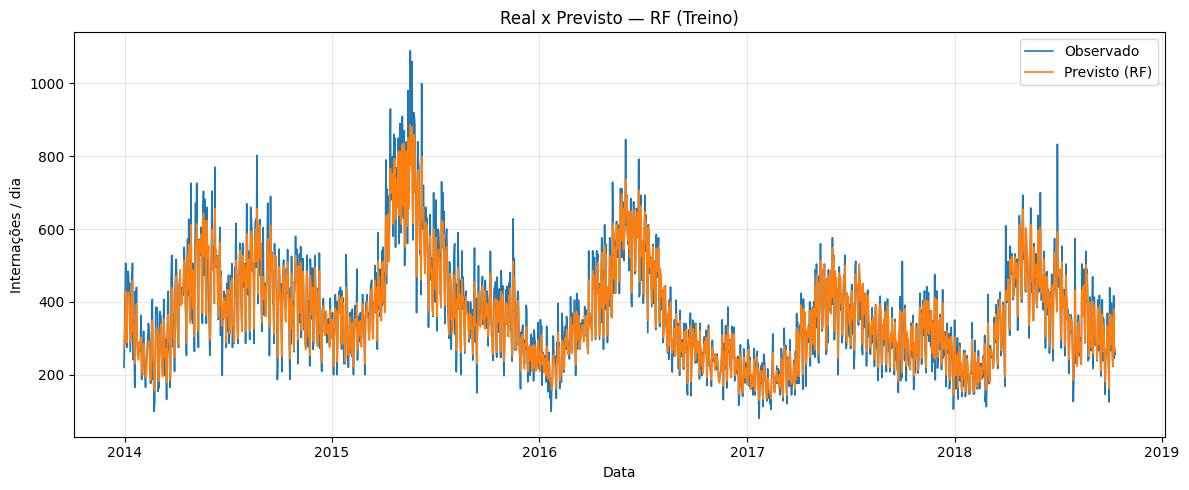

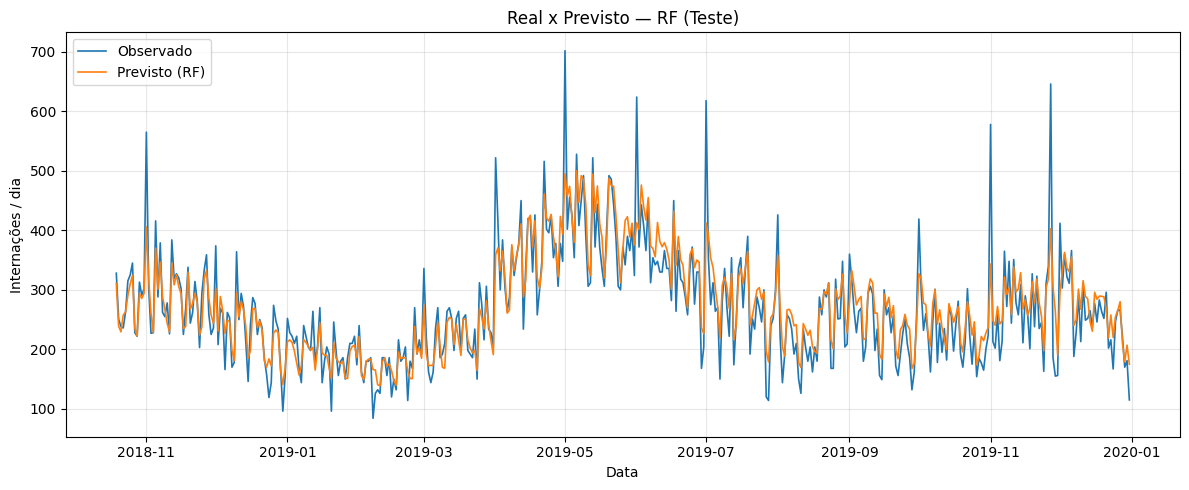


===== Árvore 0 do RF (resumo) =====
|--- o3_ma150_s1 <= 7.61
|   |--- ma_3 <= 404.00
|   |   |--- no_t <= 1.80
|   |   |   |--- is_weekend <= 0.50
|   |   |   |   |--- ma_7 <= 292.86
|   |   |   |   |   |--- ma_3 <= 262.67
|   |   |   |   |   |   |--- no_lag1 <= 1.65
|   |   |   |   |   |   |   |--- value: [5.57]
|   |   |   |   |   |   |--- no_lag1 >  1.65
|   |   |   |   |   |   |   |--- value: [5.44]
|   |   |   |   |   |--- ma_3 >  262.67
|   |   |   |   |   |   |--- lag_4 <= 234.50
|   |   |   |   |   |   |   |--- value: [5.58]
|   |   |   |   |   |   |--- lag_4 >  234.50
|   |   |   |   |   |   |   |--- pm2_5_ma7_s1 <= 4.60
|   |   |   |   |   |   |   |   |--- value: [5.60]
|   |   |   |   |   |   |   |--- pm2_5_ma7_s1 >  4.60
|   |   |   |   |   |   |   |   |--- value: [5.73]
|   |   |   |   |--- ma_7 >  292.86
|   |   |   |   |   |--- lag_7 <= 438.00
|   |   |   |   |   |   |--- no_lag1 <= 1.57
|   |   |   |   |   |   |   |--- estacao_cos <= -0.50
|   |   |   |   |   |   |   |

In [15]:
out_rf = run_pipeline_rf_rolling(
    df_unificado2,
    date_col='data_dia',
    target_col='y',
    # categorical_cols=['is_monday', 'is_weekend'],
    window_size=14,    # janela curta pro RF, como antes
    test_size=0.2,
    gap_days=7,
    k_features=30,
    random_state=42
)

print('\n[RF] Features usadas:', out_rf['features_kept'])
print('[RF] Métricas Treino:', out_rf['train_metrics'])
print('[RF] Métricas Teste :', out_rf['test_metrics'])


Epoch 1/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 3.0128 - mae: 3.1096 - mse: 13.5437 - val_loss: 0.4358 - val_mae: 0.4358 - val_mse: 0.2681 - learning_rate: 5.0000e-04
Epoch 2/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.0680 - mae: 1.1034 - mse: 1.8545 - val_loss: 0.4231 - val_mae: 0.4231 - val_mse: 0.2583 - learning_rate: 5.0000e-04
Epoch 3/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9859 - mae: 1.0173 - mse: 1.5888 - val_loss: 0.3423 - val_mae: 0.3423 - val_mse: 0.1836 - learning_rate: 5.0000e-04
Epoch 4/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9683 - mae: 1.0078 - mse: 1.5780 - val_loss: 0.5725 - val_mae: 0.5725 - val_mse: 0.4128 - learning_rate: 5.0000e-04
Epoch 5/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9121 - mae: 0.9401 - mse: 1.3397 - val_loss: 0.2572 - val_mae: 0.2572 - val_mse: 0.1060 - learning_rate: 5.0000e-04
Epoch 6/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.8805 - mae: 0.9060 - mse: 1.2755 - val_loss: 0.

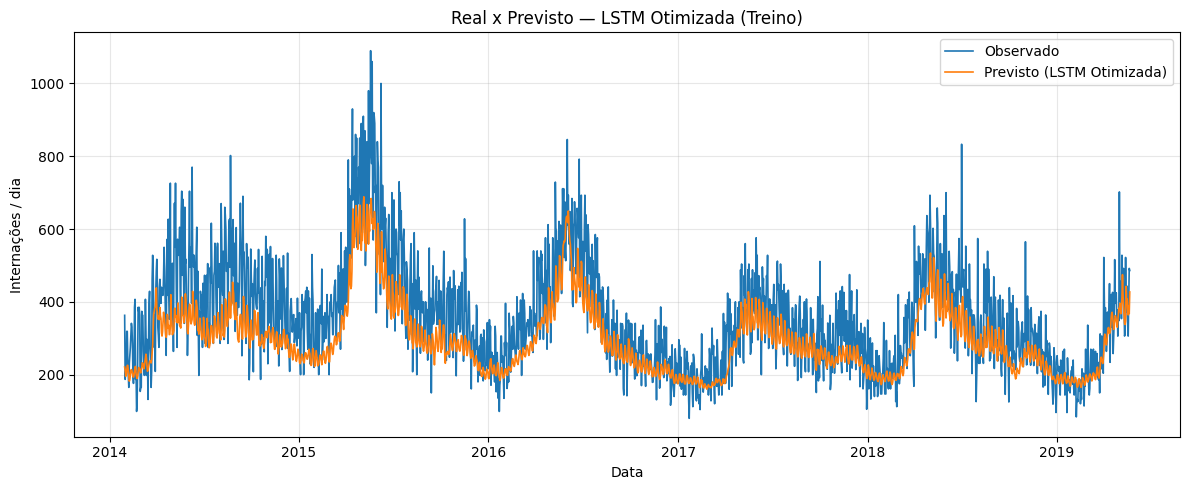

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


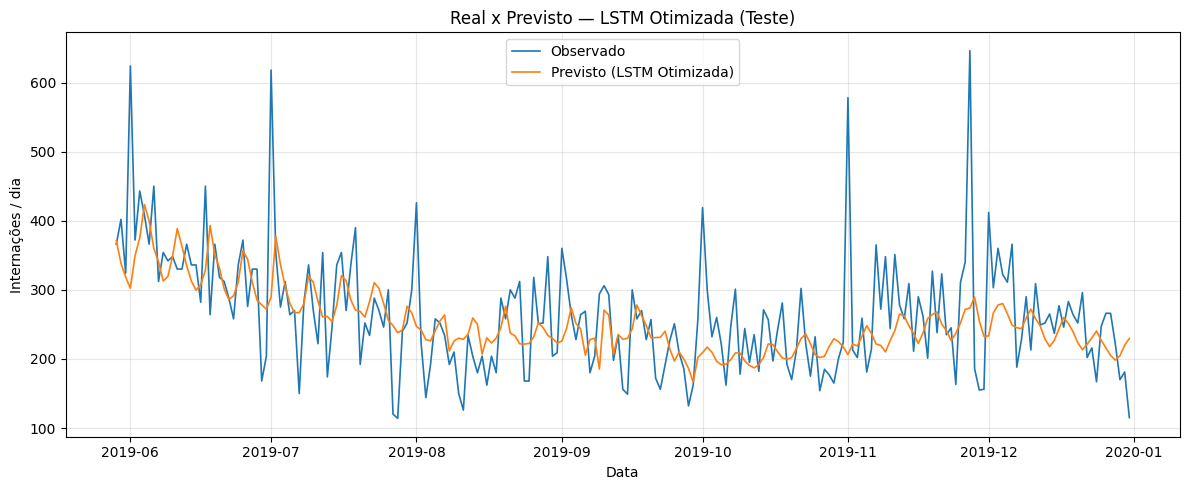


[LSTM Otimizada] Métricas Treino: {'MAE': 80.0999340848657, 'RMSE': np.float64(107.51190573987505), 'R2': 0.4695026200656164, 'sMAPE': np.float64(23.078643781388344), 'WMAPE': np.float64(22.375412025621795)}
[LSTM Otimizada] Métricas Teste : {'MAE': 51.45601200508082, 'RMSE': np.float64(75.2494020887961), 'R2': 0.21883776736746807, 'sMAPE': np.float64(19.61958770756658), 'WMAPE': np.float64(19.43223160937048)}


In [16]:
out_lstm = run_pipeline_lstm_rolling_optimized(
    df_unificado2,
    date_col='data_dia',
    target_col='y',
    categorical_cols=('Qualidade_do_Ar',),
    window_size=30,    # janela maior para capturar dinâmicas mais longas
    test_size=0.1,
    gap_days=7,
    random_state=42
)

print('\n[LSTM Otimizada] Métricas Treino:', out_lstm['train_metrics'])
print('[LSTM Otimizada] Métricas Teste :', out_lstm['test_metrics'])